In [55]:
!pip install gdown

In [56]:
!gdown --id 17kUAGnj5OhVj8yrAOae6a37jT10R01eX

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX
From (redirected): https://drive.google.com/uc?id=17kUAGnj5OhVj8yrAOae6a37jT10R01eX&confirm=t&uuid=359b5626-7df1-4cb5-9838-364b8c46b633
To: /content/neuroBrain/neuroBrain/Copy of Task01_BrainTumour.tar
100% 7.61G/7.61G [01:53<00:00, 67.2MB/s]


In [57]:
!ls -lh

total 7.1G
-rw-r--r-- 1 root root 7.1G Jul 13 19:57 'Copy of Task01_BrainTumour.tar'
drwxr-xr-x 2 root root 4.0K Jul 16 19:53  docs
drwxr-xr-x 2 root root 4.0K Jul 16 19:53  figures
-rw-r--r-- 1 root root 1.1K Jul 16 19:53  LICENSE
drwxr-xr-x 2 root root 4.0K Jul 16 19:53  models
drwxr-xr-x 2 root root 4.0K Jul 16 19:53  notebooks
-rw-r--r-- 1 root root 2.1K Jul 16 19:53  README.md
-rw-r--r-- 1 root root   74 Jul 16 19:53  requirements.txt
drwxr-xr-x 2 root root 4.0K Jul 16 19:53  results
drwxr-xr-x 3 root root 4.0K Jul 16 19:55  src


In [58]:
!tar -xf 'Copy of Task01_BrainTumour.tar'

In [59]:
!ls

'Copy of Task01_BrainTumour.tar'   models	      results
 docs				   notebooks	      src
 figures			   README.md	      Task01_BrainTumour
 LICENSE			   requirements.txt


In [60]:
!rm 'Copy of Task01_BrainTumour.tar'

In [61]:
!ls Task01_BrainTumour

dataset.json  imagesTr	imagesTs  labelsTr


In [62]:
import os

print(os.path.exists("/content/Task01_BrainTumour"))

True


In [63]:
# Install required utilities
!apt-get -qq install tree
!pip install -q nibabel

In [64]:
!git clone https://github.com/ethicalcod/neuroBrain.git
%cd neuroBrain
!git pull origin main

Cloning into 'neuroBrain'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 45 (delta 15), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 722.48 KiB | 10.32 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/neuroBrain/neuroBrain/neuroBrain
From https://github.com/ethicalcod/neuroBrain
 * branch            main       -> FETCH_HEAD
Already up to date.


In [65]:
!tree -L 2

.
├── docs
├── figures
│   ├── 01_modalities_overview.png
│   └── 02_normalization_comparison.png
├── LICENSE
├── notebooks
│   └── neuroMRI_dataset_exploration.ipynb
├── README.md
├── requirements.txt
└── src
    └── preprocessing.py

4 directories, 7 files


In [66]:
import os

folders = [
    "results",
    "models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [67]:
!tree -L 2

.
├── docs
├── figures
│   ├── 01_modalities_overview.png
│   └── 02_normalization_comparison.png
├── LICENSE
├── models
├── notebooks
│   └── neuroMRI_dataset_exploration.ipynb
├── README.md
├── requirements.txt
├── results
└── src
    └── preprocessing.py

6 directories, 7 files


In [68]:
# NeuroBrain Project Setup

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

PROJECT_ROOT = "/content/neuroBrain"

DATASET_ROOT = "/content/Task01_BrainTumour"

IMAGES_PATH = os.path.join(DATASET_ROOT, "imagesTr")
LABELS_PATH = os.path.join(DATASET_ROOT, "labelsTr")

FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

print("=" * 15)
print("NeuroBrain Project Setup")
print("=" * 15)
print("Project Root :", PROJECT_ROOT)
print("Dataset Root :", DATASET_ROOT)
print("Dataset Exists :", os.path.exists(DATASET_ROOT))

NeuroBrain Project Setup
Project Root : /content/neuroBrain
Dataset Root : /content/Task01_BrainTumour
Dataset Exists : True


In [69]:
#Loading one patient data
images = sorted([
    f for f in os.listdir(IMAGES_PATH)
    if not f.startswith("._")
])

labels = sorted([
    f for f in os.listdir(LABELS_PATH)
    if not f.startswith("._")
])

sample_path = os.path.join(IMAGES_PATH, images[0])
label_path = os.path.join(LABELS_PATH, labels[0])

image = nib.load(sample_path)
label = nib.load(label_path)

image_np = image.get_fdata()
label_np = label.get_fdata()

print(image_np.shape)
print(label_np.shape)

(240, 240, 155, 4)
(240, 240, 155)


# Research Question

Are MRI intensity values consistent across modalities, or do they require normalization before training a deep learning model?

### Objectives

- Analyze the intensity distribution of each MRI modality.
- Investigate the presence of background voxels.
- Understand why normalization is necessary.
- Build a reusable preprocessing pipeline.

In [70]:
# Intensity Statistics

modalities = ["FLAIR", "T1", "T1ce", "T2"]

for i, modality in enumerate(modalities):

    img = image_np[:, :, :, i]

    print("=" * 15)
    print(modality)
    print("=" * 15)

    print(f"Minimum : {img.min():.3f}")
    print(f"Maximum : {img.max():.3f}")
    print(f"Mean    : {img.mean():.3f}")
    print(f"Std Dev : {img.std():.3f}")
    print()

FLAIR
Minimum : 0.000
Maximum : 1829.000
Mean    : 86.020
Std Dev : 210.889

T1
Minimum : 0.000
Maximum : 2155.000
Mean    : 130.183
Std Dev : 302.973

T1ce
Minimum : 0.000
Maximum : 2239.000
Mean    : 121.466
Std Dev : 288.591

T2
Minimum : 0.000
Maximum : 1669.000
Mean    : 78.686
Std Dev : 195.858



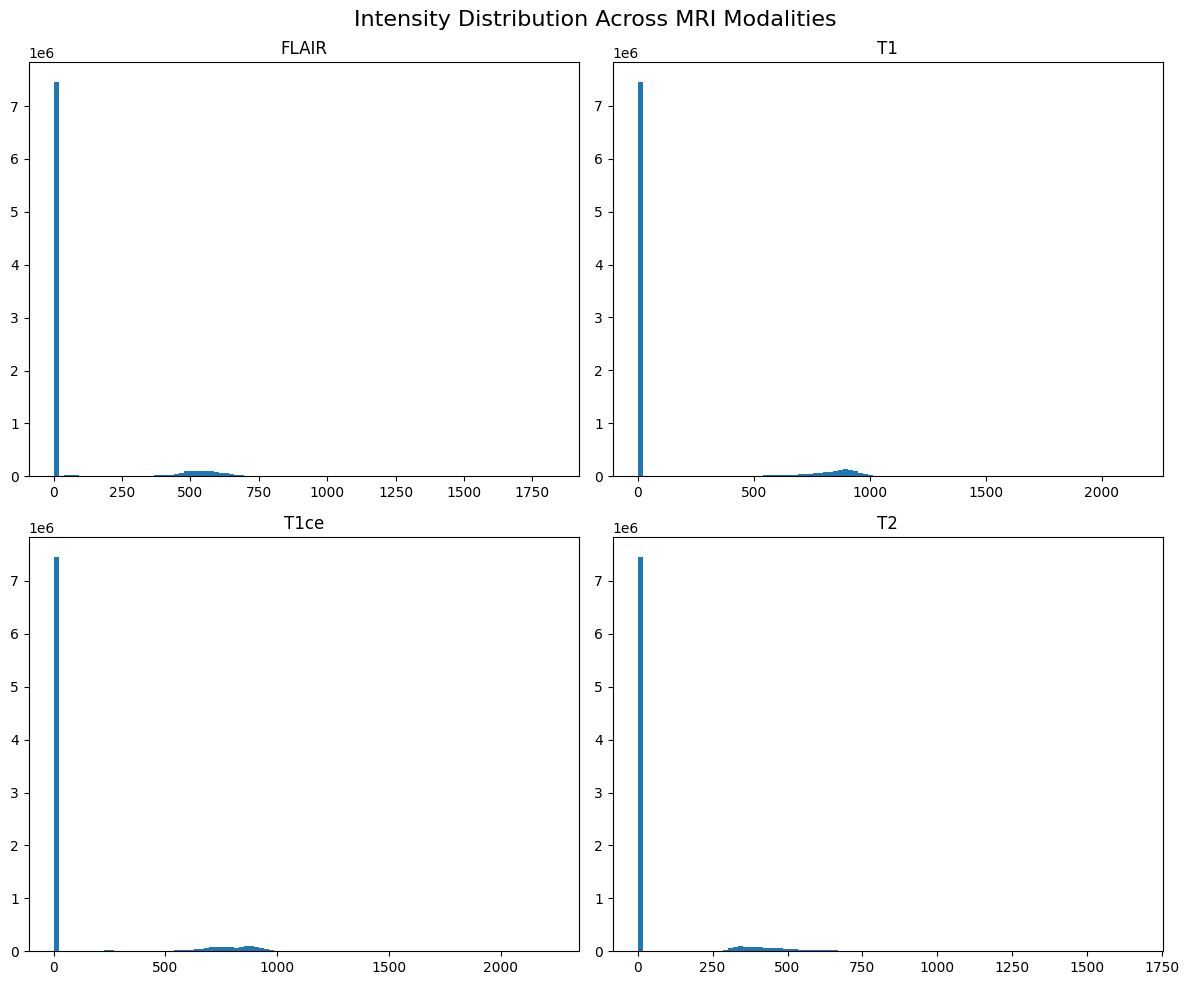

In [71]:
# Intensity Histograms

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modalities = ["FLAIR", "T1", "T1ce", "T2"]

for i in range(4):

    img = image_np[:, :, :, i].flatten()

    axes.flat[i].hist(img,
                      bins=100)

    axes.flat[i].set_title(modalities[i])

plt.suptitle("Intensity Distribution Across MRI Modalities",
             fontsize=16)

plt.tight_layout()

plt.show()

## Observations

The four MRI modalities exhibit different intensity ranges and statistical properties, confirming that raw MRI intensities are not standardized.

The histograms reveal a dominant peak at zero intensity across all modalities, corresponding to background voxels outside the brain.

Including these background voxels when computing normalization statistics would bias the mean and standard deviation. Therefore, intensity normalization should be performed using only non-zero voxels.

In [72]:
# Intensity Statistics Across Multiple Patients

modalities = ["FLAIR", "T1", "T1ce", "T2"]

num_patients = 20

for m, modality in enumerate(modalities):

    means = []
    stds = []

    for filename in images[:num_patients]:

        img = nib.load(os.path.join(IMAGES_PATH, filename)).get_fdata()

        volume = img[:, :, :, m]

        # Ignore background voxels
        brain = volume[volume > 0]

        means.append(brain.mean())
        stds.append(brain.std())

    print("=" * 15)
    print(modality)
    print("=" * 15)
    print(f"Mean intensity : {np.mean(means):.2f}")
    print(f"Std intensity  : {np.mean(stds):.2f}")
    print()

FLAIR
Mean intensity : 613.29
Std intensity  : 224.04

T1
Mean intensity : 738.32
Std intensity  : 210.36

T1ce
Mean intensity : 639.28
Std intensity  : 231.61

T2
Mean intensity : 508.91
Std intensity  : 205.07



## Conclusions

Analysis of 20 patients showed that MRI intensity statistics differ across modalities even after excluding background voxels.

Therefore, a normalization step is required before model training.

Normalization will be performed independently for each modality using only non-zero voxels to avoid bias introduced by background regions.

In [73]:
%%writefile src/preprocessing.py

import numpy as np


def normalize_nonzero(volume):
    """
    Normalize a 3D MRI volume using only non-zero voxels.

    Parameters
    ----------
    volume : np.ndarray
        Input MRI volume.

    Returns
    -------
    np.ndarray
        Normalized MRI volume.
    """

    normalized = volume.copy().astype(np.float32)

    mask = volume > 0

    if np.any(mask):
        mean = volume[mask].mean()
        std = volume[mask].std()

        if std > 0:
            normalized[mask] = (volume[mask] - mean) / std

    return normalized

Overwriting src/preprocessing.py


In [74]:
from src.preprocessing import normalize_nonzero

In [75]:
flair = image_np[:, :, :, 0]

normalized = normalize_nonzero(flair)

In [76]:
!cat src/preprocessing.py


import numpy as np


def normalize_nonzero(volume):
    """
    Normalize a 3D MRI volume using only non-zero voxels.

    Parameters
    ----------
    volume : np.ndarray
        Input MRI volume.

    Returns
    -------
    np.ndarray
        Normalized MRI volume.
    """

    normalized = volume.copy().astype(np.float32)

    mask = volume > 0

    if np.any(mask):
        mean = volume[mask].mean()
        std = volume[mask].std()

        if std > 0:
            normalized[mask] = (volume[mask] - mean) / std

    return normalized


In [77]:
mask = flair > 0

print("Mean:", normalized[mask].mean())
print("Std :", normalized[mask].std())

Mean: 2.2320453e-08
Std : 0.9999999


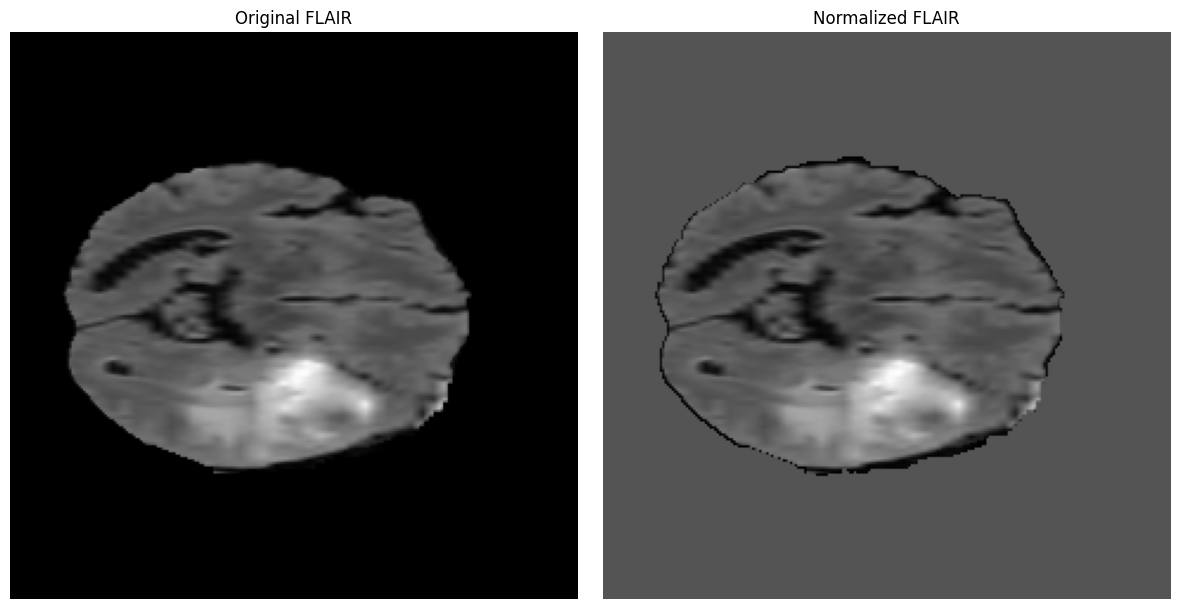

In [78]:
slice_idx = 66

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(flair[:, :, slice_idx], cmap="gray")
ax[0].set_title("Original FLAIR")
ax[0].axis("off")

ax[1].imshow(normalized[:, :, slice_idx], cmap="gray")
ax[1].set_title("Normalized FLAIR")
ax[1].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "02_normalization_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Conclusions

- MRI intensities are not standardized.
- Background occupies a substantial portion of each volume.
- Non-zero voxel normalization avoids bias in intensity statistics.

In [95]:
!git config --global user.name Shashi
!git config --global user.email 173938981+ethicalcod@users.noreply.github.com




In [80]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


### Dataset Analysis

## Research Question

Brain tumor segmentation is a highly imbalanced problem because tumor regions occupy only a small fraction of the MRI volume.

This section investigates the distribution of tumor labels and discusses its implications for model training and evaluation.

### Objectives

- Quantify voxel counts for each class.
- Visualize class imbalance.
- Understand why accuracy is an inappropriate metric.
- Motivate the use of Dice-based loss functions.

In [81]:
# Analysing a single patient
# Voxel Count per Class

unique_labels = np.unique(label_np)

print("=" * 15)
print("Voxel Counts")
print("=" * 15)

for label in unique_labels:
    count = np.sum(label_np == label)
    percentage = 100 * count / label_np.size

    print(
        f"Class {int(label)} : "
        f"{count:,} voxels "
        f"({percentage:.2f}%)"
    )

Voxel Counts
Class 0 : 8,816,276 voxels (98.75%)
Class 1 : 53,050 voxels (0.59%)
Class 2 : 27,189 voxels (0.30%)
Class 3 : 31,485 voxels (0.35%)


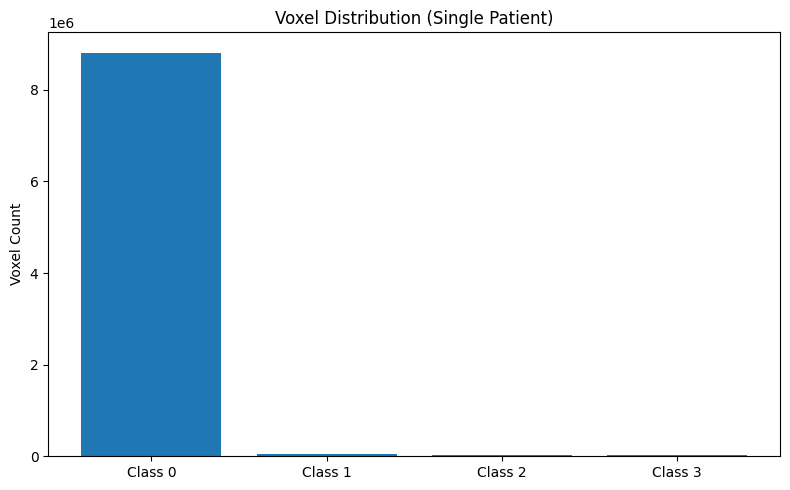

In [87]:
#Visualizing class distribution

class_names = []
voxel_counts = []

for label in unique_labels:
    class_names.append(f"Class {int(label)}")
    voxel_counts.append(np.sum(label_np == label))

plt.figure(figsize=(8,5))

plt.bar(class_names, voxel_counts)

plt.title("Voxel Distribution (Single Patient)")
plt.ylabel("Voxel Count")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "03_single_patient_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

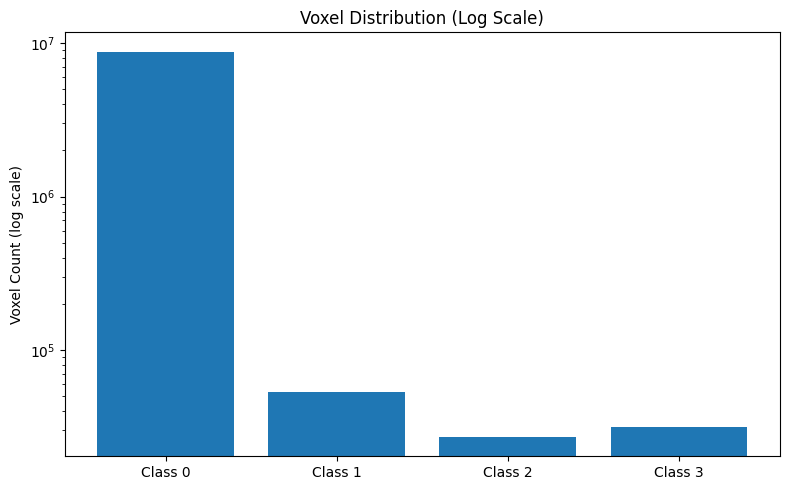

In [88]:
"""
The background class is usually orders of magnitude larger than the tumor classes. A linear-scale bar chart can make the tumor bars almost invisible. So using a logarithmic y-axis.
"""
plt.figure(figsize=(8,5))

plt.bar(labels, counts)

plt.yscale("log")

plt.title("Voxel Distribution (Log Scale)")
plt.ylabel("Voxel Count (log scale)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "04_single_patient_class_distribution_log.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Discussion

The background class dominates the MRI volume, while tumor regions occupy only a very small percentage of voxels.

This severe class imbalance makes overall accuracy an unreliable evaluation metric because a model predicting only background could still achieve high accuracy.

Therefore, overlap-based metrics such as the Dice coefficient and Dice loss are more appropriate for training and evaluation.



Voxel analysis revealed a highly imbalanced class distribution.

Approximately 98.75% of all voxels belong to the background class, while the three tumor classes together account for only about 1.25% of the MRI volume.

Such imbalance makes overall accuracy an unsuitable evaluation metric because a model predicting only background could still achieve very high accuracy.

Consequently, overlap-based metrics such as the Dice coefficient and IoU are better suited for evaluating segmentation performance. Similarly, Dice-based loss functions are expected to provide more effective optimization during training.

In [91]:
# Recover Label File List

label_files = sorted([
    f for f in os.listdir(LABELS_PATH)
    if not f.startswith("._")
])

print(f"Found {len(label_files)} label files.")
print(label_files[:5])

Found 484 label files.
['BRATS_001.nii.gz', 'BRATS_002.nii.gz', 'BRATS_003.nii.gz', 'BRATS_004.nii.gz', 'BRATS_005.nii.gz']


In [97]:
# Dataset-wide Class Distribution

from collections import Counter

class_counts = Counter()

for filename in label_files:

    label_path = os.path.join(LABELS_PATH, filename)

    mask = nib.load(label_path).get_fdata()

    unique, counts = np.unique(mask, return_counts=True)

    for u, c in zip(unique, counts):
        class_counts[int(u)] += int(c)

print("=" * 15)
print("Dataset-wide Voxel Distribution")
print("=" * 15)

total_voxels = sum(class_counts.values())

for cls in sorted(class_counts.keys()):
    percentage = 100 * class_counts[cls] / total_voxels

    print(
        f"Class {cls}: "
        f"{class_counts[cls]:,} voxels "
        f"({percentage:.4f}%)"
    )

Dataset-wide Voxel Distribution
Class 0: 4,271,154,985 voxels (98.8430%)
Class 1: 31,456,687 voxels (0.7280%)
Class 2: 8,731,567 voxels (0.2021%)
Class 3: 9,808,761 voxels (0.2270%)


## Dataset-wide Discussion

Analysis of all 484 training volumes confirmed that the dataset exhibits severe class imbalance.

Approximately 98.84% of all voxels correspond to background tissue, while only 1.16% belong to tumor regions.

Furthermore, the tumor subregions are themselves imbalanced, with Class 1 occurring substantially more frequently than Classes 2 and 3.

These findings justify the use of overlap-based loss functions (e.g., Dice Loss) and evaluation metrics (e.g., Dice Coefficient and IoU), as conventional accuracy would be dominated by the background class and provide a misleading assessment of model performance.

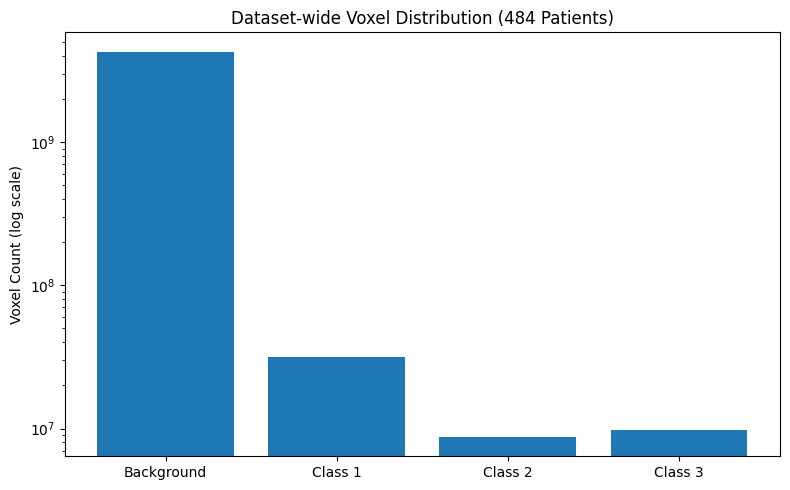

In [112]:
#Figure for dataset-wide class distribution

class_names = ["Background", "Class 1", "Class 2", "Class 3"]

dataset_counts = [
    class_counts[0],
    class_counts[1],
    class_counts[2],
    class_counts[3],
]

plt.figure(figsize=(8,5))
plt.bar(class_names, dataset_counts)
plt.yscale("log")
plt.title("Dataset-wide Voxel Distribution (484 Patients)")
plt.ylabel("Voxel Count (log scale)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "05_dataset_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
!git status
!git add .
!git commit -m "Completing Preprocessing"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
